In [12]:
import ctypes
import numpy as np
import pandas as pd
import os
import plotly as plt 
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display


In [2]:
# === Charger la DLL Rust ===
lib = ctypes.CDLL("target/release/mymodel.dll")

In [3]:
# === Définir les signatures ===
lib.create_linear_model.argtypes = [ctypes.c_size_t, ctypes.c_double, ctypes.c_size_t]
lib.create_linear_model.restype = ctypes.c_void_p

In [4]:
lib.train_linear_model_sigmoid.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_double),
    ctypes.c_size_t,
    ctypes.c_size_t,
]
lib.predict_linear_model_sigmoid.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_double), ctypes.c_size_t]
lib.predict_linear_model_sigmoid.restype = ctypes.c_double

In [5]:
# === Charger le dataset ===
df_train = pd.read_csv("dataset_train.csv")
df_test = pd.read_csv("dataset_test.csv")

X_train = df_train.drop(columns=["label"]).to_numpy(dtype=np.float64)
y_train = df_train["label"].to_numpy(dtype=np.int32)

X_test = df_test.drop(columns=["label"]).to_numpy(dtype=np.float64)
y_test = df_test["label"].to_numpy(dtype=np.int32)

n_samples, n_features = X_train.shape
n_classes = len(np.unique(y_train))

In [6]:
# === Créer et entraîner les modèles One-vs-All ===
models = []

for class_idx in range(n_classes):
    # Labels binaires pour cette classe vs toutes les autres
    y_binary = np.where(y_train == class_idx, 1.0, 0.0)

    model = lib.create_linear_model(n_features, 0.001, 3000)

    x_ptr = X_train.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
    y_ptr = y_binary.ctypes.data_as(ctypes.POINTER(ctypes.c_double))

    lib.train_linear_model_sigmoid(model, x_ptr, y_ptr, n_samples, n_features)
    models.append(model)

In [7]:
# === Prédiction sur le dataset de test ===

def predict_one_vs_all(models, x):
    x_ptr = x.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
    scores = [lib.predict_linear_model_sigmoid(model, x_ptr, len(x)) for model in models]
    return np.argmax(scores)

y_pred = np.array([predict_one_vs_all(models, x) for x in X_test])


In [8]:
# === Évaluer les performances ===
accuracy = np.mean(y_pred == y_test) * 100
print(f"Taux de bonne classification sur test (multiclasse avec sigmoïde) : {accuracy:.2f}%")

Taux de bonne classification sur test (multiclasse avec sigmoïde) : 0.00%


Nombre d'images : 36
Taille de y_test : 34
Taille de y_pred : 34
Image 300.jpeg — Prédit : 9 | Réel : A


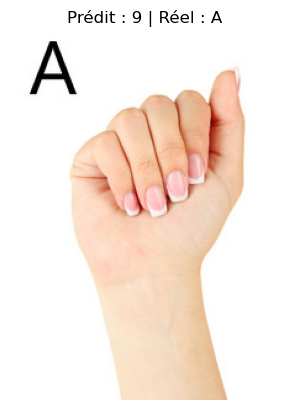

Image A_001.jpg — Prédit : 9 | Réel : A


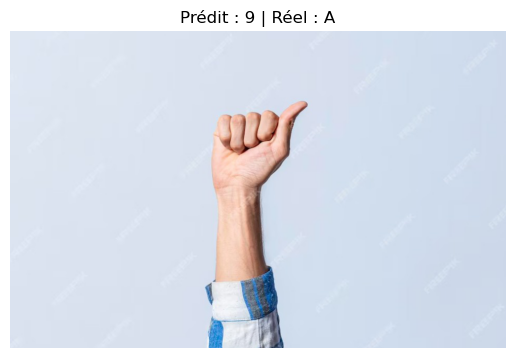

Image A_002.jpg — Prédit : 9 | Réel : A


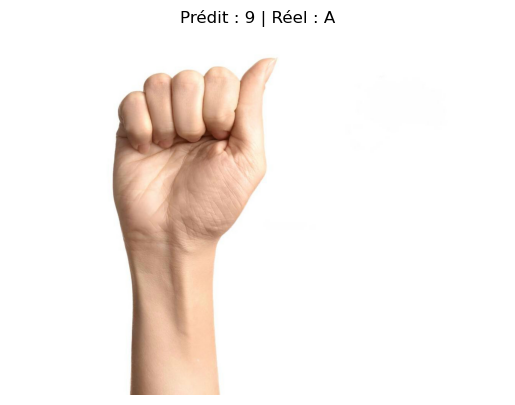

UnidentifiedImageError: cannot identify image file 'C:\\Users\\akric\\OneDrive\\Documents\\maching_learning\\projet_annuel\\PA\\dataset\\test\\A\\A_003.jpg'

In [13]:

# === Générer les chemins des images test ===
test_image_paths = []
for root, _, files in os.walk("dataset/test"):
    for file in sorted(files):  # tri pour garder un ordre constant
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            test_image_paths.append(os.path.join(root, file))

# === Liste des étiquettes (label → classe) ===
label_map = [chr(ord('A') + i) for i in range(26)] + [str(i) for i in range(10)]
# A → 0, B → 1, ..., Z → 25, 0 → 26, ..., 9 → 35

# === Affichage image + prédiction ===
print(f"Nombre d'images : {len(test_image_paths)}")
print(f"Taille de y_test : {len(y_test)}")
print(f"Taille de y_pred : {len(y_pred)}")

for i, path in enumerate(test_image_paths):
    if i >= len(y_pred):
        break

    img = Image.open(path)

    pred_label = label_map[y_pred[i]]
    true_label = label_map[y_test[i]]

    print(f"Image {os.path.basename(path)} — Prédit : {pred_label} | Réel : {true_label}")
    plt.imshow(img)
    plt.title(f"Prédit : {pred_label} | Réel : {true_label}")
    plt.axis("off")
    plt.show()
